# Transfer Learning in PyTorch

This notebook is a hands-on guide to transfer learning for computer vision. We start with the classic *frozen backbone + new head* recipe and progressively unlock more powerful (and more nuanced) strategies.

**Roadmap:**

| Section | Strategy | Architecture |
|---------|-----------|--------------|
| 3 | Frozen backbone, replace head | ResNet-18 (torchvision) |
| 4 | Unfreeze last block (partial fine-tune) | ResNet-18 |
| 5 | Custom head: Conv → GAP → MLP | ResNet-18 |
| 6 | Differential LR per block | ResNet-18 |
| 7 | `timm` — MobileNetV3, EfficientNet | timm |
| 8 | Vision Transformer (ViT) | timm |
| 9 | Custom heads deep-dive | timm |
| 10 | Feature extraction & embedding visualisation | any model |
| 11 | Comparison table + best practices |  |
| 12 | Exercises |  |

> **Runs on Colab GPU.** Runtime → Change runtime type → T4 GPU.

## [Open in Colab](https://colab.research.google.com/github/MVRonkin/DLCVCourseEn/tree/main/WS/WS3_Transfer_Learning.ipynb)

## Why transfer learning?

Training a modern CNN from scratch on a small dataset (< 10k images) is almost always a bad idea:

* The network never sees enough diversity → overfits badly.
* Millions of parameters need to be estimated from hundreds of examples.

A model pre-trained on ImageNet-1k (1.2M images, 1000 classes) has already learned:
* **Low-level features** (edges, textures, colours) in early layers.
* **Mid-level features** (parts, patterns) in middle layers.
* **High-level semantics** (object categories) in the last layers.

The key insight: *the first layers are nearly universal*, so we can reuse them for any vision task and only adapt the last layers.

```
ImageNet model  →  freeze backbone  →  replace head  →  train on small dataset
```

# 1. Setup

In [ ]:
!pip install --quiet -U timm torchinfo

In [1]:
import os, copy, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
from torchvision import transforms, datasets
from torchvision.datasets.utils import download_and_extract_archive
from torchinfo import summary
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import timm
import ssl
ssl._create_default_https_context = ssl._create_stdlib_context

In [2]:
# ── Reproducibility & device ─────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark     = True
    torch.backends.cudnn.deterministic = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cpu


# 2. Dataset — Bees vs Ants

We use the classic 2-class dataset from the PyTorch transfer learning tutorial:
* **245 training** images (ants + bees)
* **153 validation** images

This is intentionally tiny — it's exactly the regime where transfer learning shines most.

In [3]:
url = 'https://download.pytorch.org/tutorial/hymenoptera_data.zip'
root_dir = os.path.join(os.getcwd(), 'data')
dataset_dir = os.path.splitext(os.path.join(root_dir, url.split('/')[-1]))[0]
download_and_extract_archive(url, root_dir)

# ImageNet normalisation — required by any ImageNet-pretrained backbone
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_tfm = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

trainset = datasets.ImageFolder(os.path.join(dataset_dir, 'train'), train_tfm)
valset   = datasets.ImageFolder(os.path.join(dataset_dir, 'val'),   val_tfm)
CLASS_NAMES = trainset.classes
N_CLASSES   = len(CLASS_NAMES)
print(f'Classes: {CLASS_NAMES}  |  train={len(trainset)}, val={len(valset)}')

Classes: ['ants', 'bees']  |  train=244, val=153


In [4]:
BATCH_SIZE  = 16
num_workers = min(2, os.cpu_count())
pin_memory  = (device.type == 'cuda')

trainloader = data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=num_workers, pin_memory=pin_memory)
valloader   = data.DataLoader(valset,   batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=num_workers, pin_memory=pin_memory)

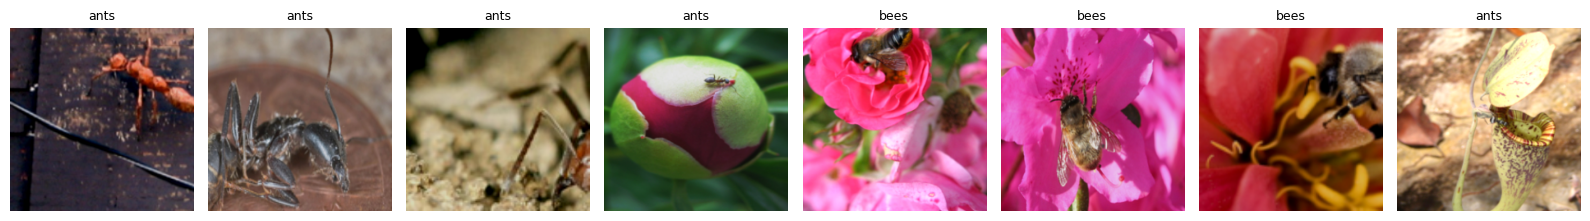

In [5]:
def denorm(t):
    t = t.clone().cpu()
    for c, (m, s) in enumerate(zip(MEAN, STD)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

def show_batch(loader, n=8):
    x, y = next(iter(loader))
    fig, axs = plt.subplots(1, n, figsize=(n * 2, 2.5))
    for i, ax in enumerate(axs):
        ax.imshow(denorm(x[i]).permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[y[i].item()], fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

show_batch(trainloader)

# 3. Training infrastructure

We write the training loop **once** and reuse it across all experiments. The `fit` function supports:
* any `torch.optim` optimizer + scheduler
* early stopping
* best-model checkpointing
* returns a `pd.DataFrame` history for easy plotting

In [6]:
def accuracy(y_pred, y):
    return y_pred.argmax(1).eq(y).float().mean()

def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None: nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None: nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
        if m.weight is not None: nn.init.ones_(m.weight)
        if m.bias   is not None: nn.init.zeros_(m.bias)

def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Trainable: {trainable:,}  /  Total: {total:,}  '
          f'({100*trainable/total:.2f}%)')
    return trainable, total

In [7]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    loss_sum = acc_sum = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        acc_sum  += accuracy(out, y).item()
    return loss_sum / len(loader), acc_sum / len(loader)

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum = acc_sum = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out  = model(x)
        loss_sum += criterion(out, y).item()
        acc_sum  += accuracy(out, y).item()
    return loss_sum / len(loader), acc_sum / len(loader)

In [8]:
def fit(model, train_loader, val_loader, optimizer, criterion,
        epochs=10, scheduler=None, device='cpu',
        checkpoint='best.pt', patience=None, verbose=True):
    best_val_loss = float('inf')
    no_improve    = 0
    history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','lr','t']}

    for epoch in range(epochs):
        t0 = time.monotonic()
        tr_loss, tr_acc   = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = eval_epoch (model, val_loader,  criterion, device)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        improved = val_loss < best_val_loss
        if improved:
            best_val_loss = val_loss
            torch.save(model.state_dict(), checkpoint)
            no_improve = 0
        else:
            no_improve += 1

        lr = optimizer.param_groups[0]['lr']
        elapsed = time.monotonic() - t0
        for k, v in zip(history, [tr_loss, val_loss, tr_acc, val_acc, lr, elapsed]):
            history[k].append(v)

        if verbose and (epoch == 0 or (epoch + 1) % 5 == 0 or improved):
            star = ' ★' if improved else ''
            print(f'Ep {epoch+1:02d}/{epochs} | {elapsed:.1f}s | lr {lr:.1e} | '
                  f'train {tr_loss:.3f}/{tr_acc:.3f} | '
                  f'val {val_loss:.3f}/{val_acc:.3f}{star}')

        if patience and no_improve >= patience:
            print(f'Early stop at epoch {epoch+1}.')
            break

    return pd.DataFrame(history)


def plot_history(df, title=''):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    axs[0].plot(df['train_loss'], label='train'); axs[0].plot(df['val_loss'], label='val')
    axs[0].set_title(f'{title} — loss'); axs[0].legend(); axs[0].grid(alpha=.3)
    axs[1].plot(df['train_acc'],  label='train'); axs[1].plot(df['val_acc'],  label='val')
    axs[1].set_title(f'{title} — accuracy'); axs[1].legend(); axs[1].grid(alpha=.3)
    axs[2].plot(df['lr']); axs[2].set_title('LR schedule')
    axs[2].set_yscale('log'); axs[2].grid(alpha=.3)
    plt.tight_layout(); plt.show()

# Results accumulator
results = []
def register(name, model, hist, ckpt, note=''):
    model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
    _, val_acc = eval_epoch(model, valloader, nn.CrossEntropyLoss(), device)
    tr, tot = count_params(model)
    results.append({'model': name, 'note': note,
                    'trainable': f'{tr:,}', 'total': f'{tot:,}',
                    'best_val_acc': f'{hist["val_acc"].max():.4f}',
                    'final_val_acc': f'{val_acc:.4f}'})
    print(f'[{name}]  val_acc={val_acc:.4f}')

# 4. Strategy 1 — Frozen backbone + replace head

This is the simplest and most robust strategy for small datasets.

**Steps:**
1. Load ResNet-18 with ImageNet weights.
2. Freeze **all** parameters.
3. Replace the `fc` layer with a new one for our `N_CLASSES`.
4. Train **only** the new head.

**When to use:** < 1k images, target domain similar to ImageNet (natural photos).

In [9]:
# ── Load pretrained ResNet-18 ─────────────────────────────────────────────
model_s1 = torchvision.models.resnet18(weights='IMAGENET1K_V1')

# ── Freeze everything ────────────────────────────────────────────────────
for p in model_s1.parameters():
    p.requires_grad = False

# ── Replace head ─────────────────────────────────────────────────────────
n_in = model_s1.fc.in_features           # 512 for ResNet-18
model_s1.fc = nn.Linear(n_in, N_CLASSES)
nn.init.xavier_uniform_(model_s1.fc.weight)
nn.init.zeros_(model_s1.fc.bias)

print('ResNet-18 children:', [n for n, _ in model_s1.named_children()])
count_params(model_s1)

ResNet-18 children: ['conv1', 'bn1', 'relu', 'maxpool', 'layer1', 'layer2', 'layer3', 'layer4', 'avgpool', 'fc']
Trainable: 1,026  /  Total: 11,177,538  (0.01%)


(1026, 11177538)

In [10]:
model_s1 = model_s1.to(device)
crit = nn.CrossEntropyLoss()

# Only pass trainable params to the optimiser
opt_s1   = optim.AdamW(filter(lambda p: p.requires_grad, model_s1.parameters()),
                       lr=1e-3, weight_decay=1e-4)
sched_s1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_s1, T_max=15)

print('Accuracy before training:')
_, acc0 = eval_epoch(model_s1, valloader, crit, device)
print(f'  val_acc = {acc0:.4f}  (random head, frozen backbone)')

Accuracy before training:
  val_acc = 0.5750  (random head, frozen backbone)


Ep 01/15 | 11.6s | lr 9.9e-04 | train 0.722/0.645 | val 0.634/0.684 ★
Ep 02/15 | 9.0s | lr 9.6e-04 | train 0.535/0.719 | val 0.463/0.834 ★
Ep 03/15 | 14.3s | lr 9.0e-04 | train 0.486/0.773 | val 0.386/0.865 ★
Ep 04/15 | 9.3s | lr 8.3e-04 | train 0.385/0.844 | val 0.340/0.876 ★
Ep 05/15 | 11.2s | lr 7.5e-04 | train 0.371/0.820 | val 0.313/0.889 ★
Ep 06/15 | 12.5s | lr 6.5e-04 | train 0.388/0.824 | val 0.274/0.914 ★
Ep 07/15 | 9.1s | lr 5.5e-04 | train 0.318/0.879 | val 0.270/0.901 ★
Ep 08/15 | 14.7s | lr 4.5e-04 | train 0.297/0.883 | val 0.257/0.919 ★
Ep 10/15 | 11.0s | lr 2.5e-04 | train 0.281/0.891 | val 0.260/0.903
Ep 11/15 | 13.6s | lr 1.7e-04 | train 0.253/0.898 | val 0.251/0.903 ★
Ep 12/15 | 9.3s | lr 9.5e-05 | train 0.295/0.875 | val 0.246/0.919 ★
Ep 15/15 | 10.3s | lr 0.0e+00 | train 0.249/0.891 | val 0.244/0.897 ★


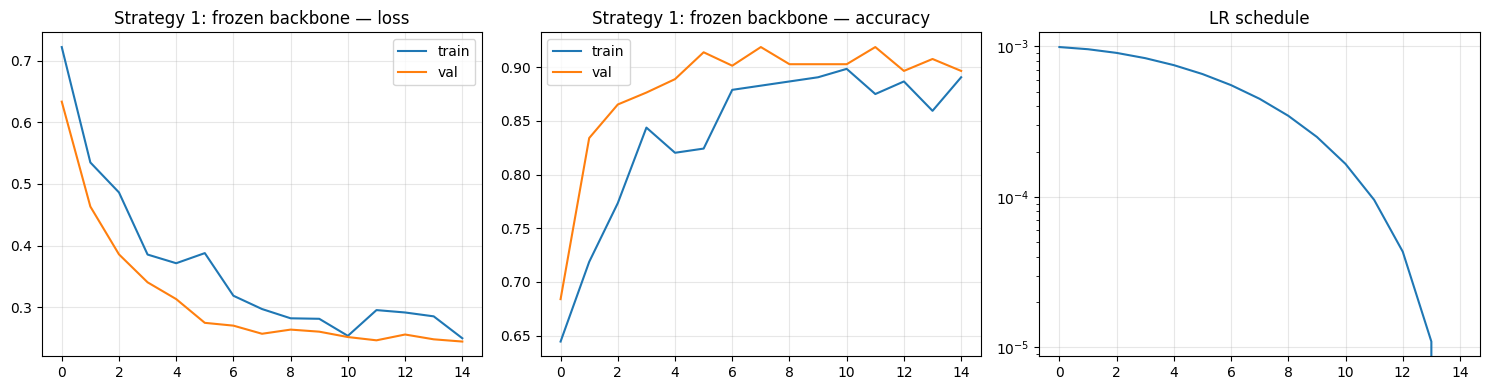

Trainable: 1,026  /  Total: 11,177,538  (0.01%)
[Frozen backbone]  val_acc=0.8965


In [11]:
EPOCHS = 15
hist_s1 = fit(model_s1, trainloader, valloader, opt_s1, crit,
              epochs=EPOCHS, scheduler=sched_s1, device=device,
              checkpoint='ckpt_s1_frozen.pt', patience=EPOCHS)
plot_history(hist_s1, 'Strategy 1: frozen backbone')
register('Frozen backbone', model_s1, hist_s1, 'ckpt_s1_frozen.pt',
         note='Only FC trained')

**Key observation:** even with 512 → 2 parameters to train (1026 total), we get excellent accuracy because the ImageNet features are already very good for distinguishing ants and bees.

> The gap between accuracy before and after training the head shows how much free signal was already in the frozen features.

# 5. Strategy 2 — Partial fine-tuning (unfreeze last block)

When the frozen backbone strategy plateaus, the next step is to unfreeze the **last residual block** and fine-tune it jointly with the head.

**Why only the last block?**
* Early layers capture universal low-level features (edges, textures) — no need to change them.
* The last block captures high-level semantics that are most task-specific.
* Unfreezing more layers risks overfitting on a small dataset.

```
Layer 1 (frozen)  → Layer 2 (frozen)  → Layer 3 (frozen)  → Layer 4 (trainable) → FC (trainable)
```

**Important:** re-initialise the unfrozen layers to prevent the optimizer from fighting large pretrained gradients.

In [12]:
model_s2 = torchvision.models.resnet18(weights='IMAGENET1K_V1')

# ── Freeze all, then selectively unfreeze ───────────────────────────────
for p in model_s2.parameters():
    p.requires_grad = False

# Unfreeze layer4 + fc
for module in [model_s2.layer4, model_s2.fc]:
    for p in module.parameters():
        p.requires_grad = True

# Replace and re-init head
model_s2.fc = nn.Linear(model_s2.fc.in_features, N_CLASSES)
model_s2.fc.apply(init_weights)

# Re-init unfrozen backbone layers too (fresh start for these layers)
model_s2.layer4.apply(init_weights)

count_params(model_s2)
print()
print('Unfrozen modules:')
for name, m in model_s2.named_modules():
    if any(p.requires_grad for p in m.parameters(recurse=False)):
        print(f'  {name}')

Trainable: 8,394,754  /  Total: 11,177,538  (75.10%)

Unfrozen modules:
  layer4.0.conv1
  layer4.0.bn1
  layer4.0.conv2
  layer4.0.bn2
  layer4.0.downsample.0
  layer4.0.downsample.1
  layer4.1.conv1
  layer4.1.bn1
  layer4.1.conv2
  layer4.1.bn2
  fc


Ep 01/15 | 11.5s | lr 4.9e-04 | train 0.867/0.746 | val 3.119/0.656 ★
Ep 02/15 | 12.0s | lr 4.8e-04 | train 0.511/0.828 | val 2.178/0.669 ★
Ep 03/15 | 13.5s | lr 4.5e-04 | train 0.421/0.852 | val 0.769/0.834 ★
Ep 04/15 | 10.0s | lr 4.2e-04 | train 0.243/0.898 | val 0.401/0.908 ★
Ep 05/15 | 15.3s | lr 3.8e-04 | train 0.220/0.926 | val 0.418/0.897
Ep 06/15 | 10.3s | lr 3.3e-04 | train 0.318/0.895 | val 0.365/0.890 ★
Ep 10/15 | 14.4s | lr 1.3e-04 | train 0.179/0.902 | val 0.468/0.872
Ep 13/15 | 11.0s | lr 2.2e-05 | train 0.167/0.941 | val 0.355/0.920 ★
Ep 15/15 | 12.9s | lr 0.0e+00 | train 0.149/0.953 | val 0.381/0.939


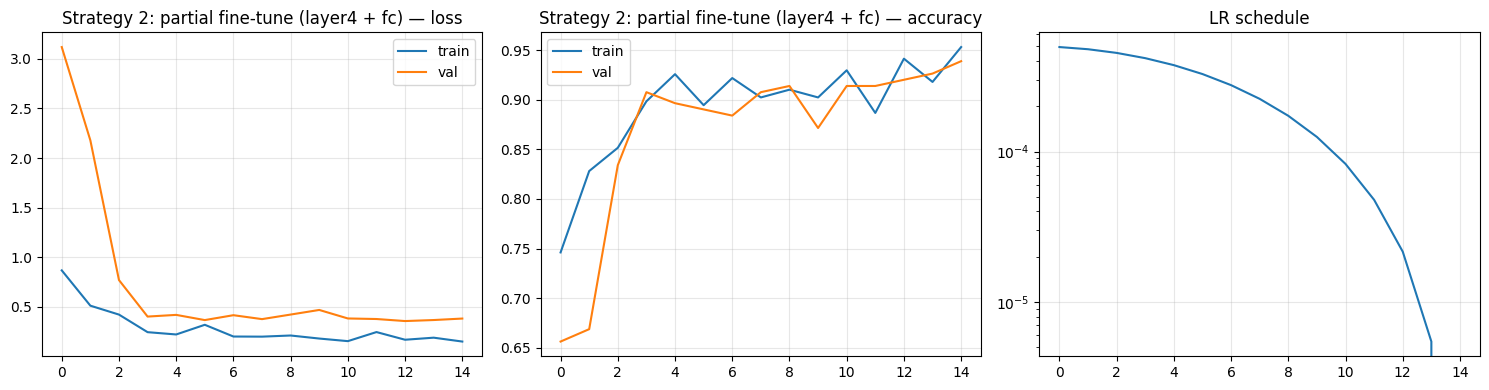

Trainable: 8,394,754  /  Total: 11,177,538  (75.10%)
[Partial fine-tune]  val_acc=0.9201


In [13]:
model_s2 = model_s2.to(device)

opt_s2   = optim.AdamW(filter(lambda p: p.requires_grad, model_s2.parameters()),
                       lr=5e-4, weight_decay=1e-4)
sched_s2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_s2, T_max=EPOCHS)

hist_s2 = fit(model_s2, trainloader, valloader, opt_s2, crit,
              epochs=EPOCHS, scheduler=sched_s2, device=device,
              checkpoint='ckpt_s2_partial.pt', patience=EPOCHS)
plot_history(hist_s2, 'Strategy 2: partial fine-tune (layer4 + fc)')
register('Partial fine-tune', model_s2, hist_s2, 'ckpt_s2_partial.pt',
         note='layer4 + FC')

# 6. Strategy 3 — Differential learning rates (LLRD)

**Problem with full fine-tuning:** using the same LR for the old pretrained layers and the new head is wrong. The head has random weights → needs a large LR. The backbone has well-trained weights → needs a tiny LR (otherwise we destroy the pretrained features).

**Solution: Layer-wise LR Decay (LLRD)**

```
FC:     lr = base_lr                       (new weights, large updates)
layer4: lr = base_lr × decay               (close to output, medium update)
layer3: lr = base_lr × decay²              (further, smaller update)
...
layer1: lr = base_lr × decay^4             (universal features, tiny update)
```

This is the standard recipe in fine-tuning ViT and large models. Here we use `decay=0.3`.

In [14]:
model_s3 = torchvision.models.resnet18(weights='IMAGENET1K_V1')
model_s3.fc = nn.Linear(model_s3.fc.in_features, N_CLASSES)
model_s3.fc.apply(init_weights)
model_s3 = model_s3.to(device)

# ── Build parameter groups with decaying LR ──────────────────────────────
BASE_LR = 5e-4
DECAY   = 0.3   # each earlier block gets LR × DECAY

layer_groups = [
    ('fc',     model_s3.fc.parameters()),
    ('layer4', model_s3.layer4.parameters()),
    ('layer3', model_s3.layer3.parameters()),
    ('layer2', model_s3.layer2.parameters()),
    ('layer1', model_s3.layer1.parameters()),
]
param_groups = []
for i, (name, params) in enumerate(layer_groups):
    group_lr = BASE_LR * (DECAY ** i)
    param_groups.append({'params': list(params), 'lr': group_lr})
    print(f'{name:8s}: lr = {group_lr:.2e}')

# Stem (conv1 + bn1) — very small LR
stem_params = list(model_s3.conv1.parameters()) + list(model_s3.bn1.parameters())
param_groups.append({'params': stem_params, 'lr': BASE_LR * (DECAY ** 5)})
print(f'{"stem":8s}: lr = {BASE_LR * DECAY**5:.2e}')

opt_s3   = optim.AdamW(param_groups, weight_decay=1e-4)
sched_s3 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_s3, T_max=EPOCHS)

fc      : lr = 5.00e-04
layer4  : lr = 1.50e-04
layer3  : lr = 4.50e-05
layer2  : lr = 1.35e-05
layer1  : lr = 4.05e-06
stem    : lr = 1.21e-06


Ep 01/15 | 19.1s | lr 4.9e-04 | train 0.589/0.770 | val 0.293/0.922 ★
Ep 04/15 | 13.2s | lr 4.2e-04 | train 0.136/0.953 | val 0.272/0.914 ★
Ep 05/15 | 18.8s | lr 3.8e-04 | train 0.295/0.902 | val 0.269/0.926 ★
Ep 10/15 | 20.6s | lr 1.3e-04 | train 0.134/0.945 | val 0.342/0.920
Ep 15/15 | 13.8s | lr 0.0e+00 | train 0.119/0.957 | val 0.303/0.945


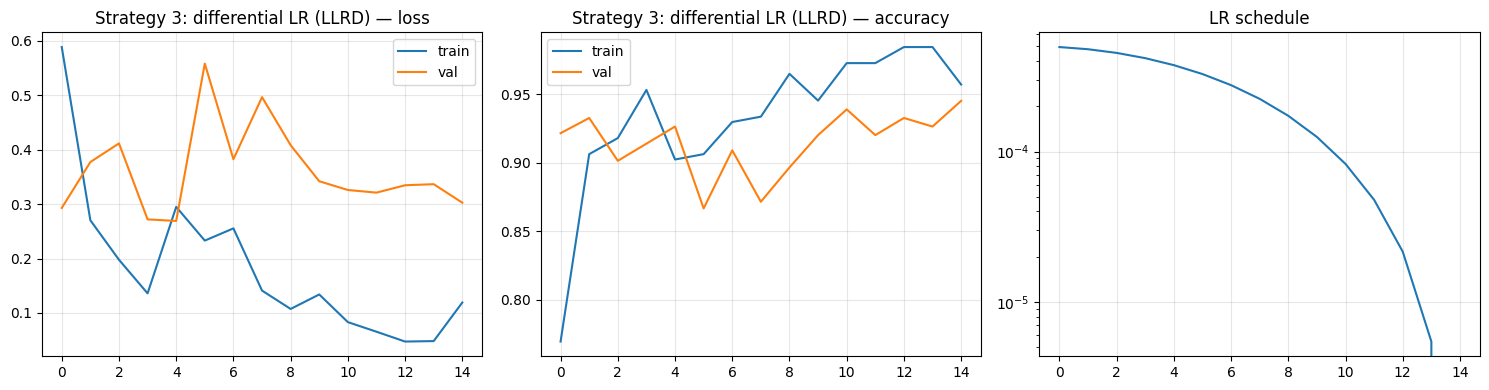

Trainable: 11,177,538  /  Total: 11,177,538  (100.00%)
[LLRD full finetune]  val_acc=0.9264


In [15]:
hist_s3 = fit(model_s3, trainloader, valloader, opt_s3, crit,
              epochs=EPOCHS, scheduler=sched_s3, device=device,
              checkpoint='ckpt_s3_llrd.pt', patience=EPOCHS)
plot_history(hist_s3, 'Strategy 3: differential LR (LLRD)')
register('LLRD full finetune', model_s3, hist_s3, 'ckpt_s3_llrd.pt',
         note='All layers, LLRD')

**Why LLRD helps:**

| Layer | Pretrained quality | Update direction |
|---|---|---|
| Early layers | Very good (universal) | Tiny nudge |
| Middle layers | Good | Small update |
| Last block | Domain-specific | Moderate update |
| Head | Random | Large update |

# 7. Strategy 4 — Custom head with Conv + GAP + Dropout

Instead of plugging a single Linear layer as the head, we can build a richer head:

```
backbone (frozen) → last feature map (512×7×7)
  → Conv(512→1024, 3×3) → BN → ReLU     ← learn task-specific features
  → GAP → (1024,)                        ← spatial aggregation
  → Dropout(0.5)                         ← regularisation
  → Linear(1024 → 256) → ReLU
  → Linear(256 → N_CLASSES)
```

Advantages:
* The extra Conv can learn to combine backbone features in task-specific ways.
* Dropout between GAP and FC regularises the head (important for small datasets).
* GAP makes the head resolution-independent.

In [16]:
class CustomHeadResNet(nn.Module):
    """
    ResNet-18 backbone (frozen) + custom head.
    The backbone is sliced at the last residual block output
    (before the original avgpool + fc).
    """
    def __init__(self, backbone, n_classes=2, hidden=256, dropout=0.5):
        super().__init__()
        # Strip avgpool and fc — keep everything up to layer4
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        for p in self.backbone.parameters():
            p.requires_grad = False

        n_feat = 512          # ResNet-18 last block output channels

        self.head = nn.Sequential(
            # Task-specific conv
            nn.Conv2d(n_feat, 1024, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),          # GAP → (B, 1024, 1, 1)
            nn.Flatten(),                     # → (B, 1024)

            nn.Dropout(dropout),
            nn.Linear(1024, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden, n_classes),
        )
        self.head.apply(init_weights)

    def forward(self, x):
        with torch.no_grad():                  # backbone stays frozen
            feats = self.backbone(x)
        return self.head(feats)


rn18 = torchvision.models.resnet18(weights='IMAGENET1K_V1')
model_s4 = CustomHeadResNet(rn18, n_classes=N_CLASSES).to(device)
count_params(model_s4)
summary(model_s4, (1, 3, 224, 224), device=device.type, depth=3)

Trainable: 4,983,554  /  Total: 16,160,066  (30.84%)


Layer (type:depth-idx)                        Output Shape              Param #
CustomHeadResNet                              [1, 2]                    --
├─Sequential: 1-1                             [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         (9,408)
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         (128)
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
│    └─Sequential: 2-5                        [1, 64, 56, 56]           --
│    │    └─BasicBlock: 3-1                   [1, 64, 56, 56]           (73,984)
│    │    └─BasicBlock: 3-2                   [1, 64, 56, 56]           (73,984)
│    └─Sequential: 2-6                        [1, 128, 28, 28]          --
│    │    └─BasicBlock: 3-3                   [1, 128, 28, 28]          (230,144)
│    │    └─BasicBlock: 3-4                   [1, 128, 28, 28]      

Ep 01/15 | 15.6s | lr 9.9e-04 | train 0.327/0.863 | val 0.254/0.940 ★
Ep 05/15 | 12.5s | lr 7.5e-04 | train 0.357/0.875 | val 0.287/0.928
Ep 07/15 | 10.1s | lr 5.5e-04 | train 0.192/0.902 | val 0.226/0.951 ★
Ep 08/15 | 16.1s | lr 4.5e-04 | train 0.212/0.914 | val 0.201/0.945 ★
Ep 10/15 | 11.5s | lr 2.5e-04 | train 0.161/0.938 | val 0.215/0.945
Ep 11/15 | 17.0s | lr 1.7e-04 | train 0.335/0.848 | val 0.184/0.951 ★
Ep 15/15 | 10.5s | lr 0.0e+00 | train 0.194/0.930 | val 0.187/0.939


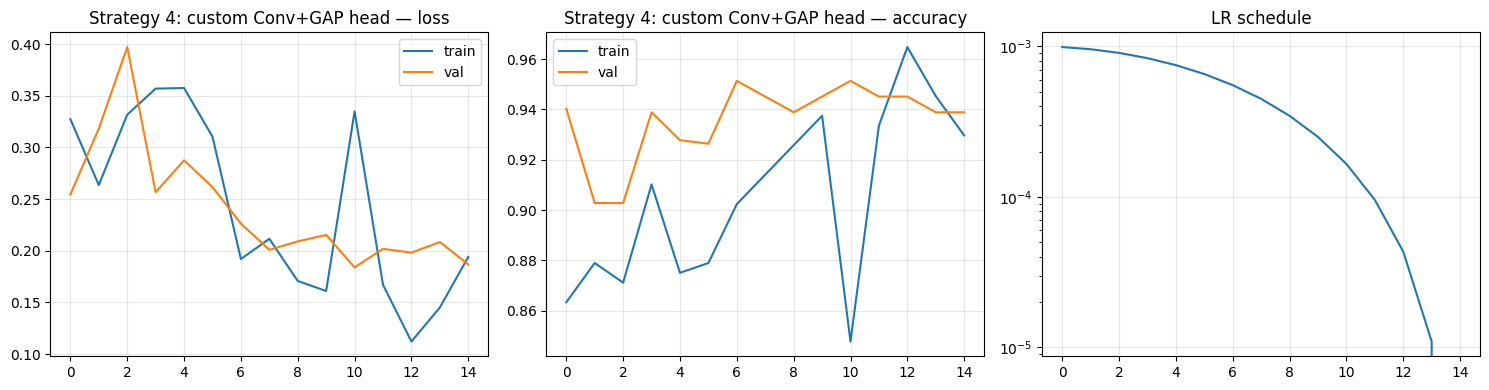

Trainable: 4,983,554  /  Total: 16,160,066  (30.84%)
[Custom head]  val_acc=0.9514


In [17]:
opt_s4   = optim.AdamW(filter(lambda p: p.requires_grad, model_s4.parameters()),
                       lr=1e-3, weight_decay=1e-4)
sched_s4 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_s4, T_max=EPOCHS)

hist_s4 = fit(model_s4, trainloader, valloader, opt_s4, crit,
              epochs=EPOCHS, scheduler=sched_s4, device=device,
              checkpoint='ckpt_s4_customhead.pt', patience=EPOCHS)
plot_history(hist_s4, 'Strategy 4: custom Conv+GAP head')
register('Custom head', model_s4, hist_s4, 'ckpt_s4_customhead.pt',
         note='Conv→GAP→Dropout→MLP')

# 8. `timm` — Transfer learning with lightweight models

[`timm`](https://huggingface.co/timm) (PyTorch Image Models) gives access to 1000+ pretrained backbones with a **uniform API**.

For **mobile / edge** deployment we need models that are fast at inference time. `MobileNetV3-Small` has only ~2.5M parameters and runs at >200 FPS on a CPU.

## `timm` API cheat-sheet

```python
# List models
timm.list_models('mobilenet*')
timm.list_models('efficientnet*')

# Create (pretrained)
model = timm.create_model('mobilenetv3_small_100', pretrained=True, num_classes=2)

# Inspect head
model.get_classifier()          # returns the head module
model.reset_classifier(n)       # replaces with Linear(feat, n)

# Inspect feature info
model.feature_info               # list of feature map info per stage
model.forward_features(x)        # backbone output before head
```

In [18]:
# ── Show some available lightweight models ───────────────────────────────
print('MobileNets:')
print(timm.list_models('mobilenet*')[:8])
print()
print('EfficientNets:')
print(timm.list_models('efficientnet_b[0-2]*')[:6])
print()
print('MobileViT:')
print(timm.list_models('mobilevit*')[:5])

MobileNets:
['mobilenet_edgetpu_100', 'mobilenet_edgetpu_v2_l', 'mobilenet_edgetpu_v2_m', 'mobilenet_edgetpu_v2_s', 'mobilenet_edgetpu_v2_xs', 'mobilenetv1_100', 'mobilenetv1_100h', 'mobilenetv1_125']

EfficientNets:
['efficientnet_b0', 'efficientnet_b0_g8_gn', 'efficientnet_b0_g16_evos', 'efficientnet_b0_gn', 'efficientnet_b1', 'efficientnet_b1_pruned']

MobileViT:
['mobilevit_s', 'mobilevit_xs', 'mobilevit_xxs', 'mobilevitv2_050', 'mobilevitv2_075']


In [19]:
# ── Load MobileNetV3-Small ────────────────────────────────────────────────
mob = timm.create_model('mobilenetv3_small_100', pretrained=True, num_classes=N_CLASSES)

# timm sets num_classes automatically — no manual head replacement needed
print('Classifier:', mob.get_classifier())
print()
count_params(mob)   # all parameters trainable (num_classes was set at load time)

Classifier: Linear(in_features=1024, out_features=2, bias=True)

Trainable: 1,519,906  /  Total: 1,519,906  (100.00%)


(1519906, 1519906)

### `timm` frozen-backbone pattern

`timm` makes it trivially easy to freeze the backbone and only train the head:

Trainable: 2,050  /  Total: 1,519,906  (0.13%)
Ep 01/15 | 11.1s | lr 9.9e-04 | train 2.833/0.570 | val 2.286/0.567 ★
Ep 03/15 | 12.9s | lr 9.0e-04 | train 2.570/0.594 | val 2.199/0.547 ★
Ep 04/15 | 10.0s | lr 8.3e-04 | train 2.276/0.602 | val 1.977/0.579 ★
Ep 05/15 | 7.3s | lr 7.5e-04 | train 1.880/0.633 | val 1.889/0.609 ★
Ep 06/15 | 14.6s | lr 6.5e-04 | train 1.948/0.641 | val 1.674/0.678 ★
Ep 07/15 | 8.9s | lr 5.5e-04 | train 1.571/0.645 | val 1.512/0.659 ★
Ep 08/15 | 7.7s | lr 4.5e-04 | train 1.588/0.715 | val 1.485/0.665 ★
Ep 10/15 | 8.0s | lr 2.5e-04 | train 1.344/0.699 | val 1.533/0.678
Ep 11/15 | 8.1s | lr 1.7e-04 | train 1.344/0.727 | val 1.475/0.659 ★
Ep 12/15 | 14.2s | lr 9.5e-05 | train 1.458/0.699 | val 1.450/0.684 ★
Ep 13/15 | 7.5s | lr 4.3e-05 | train 1.325/0.734 | val 1.417/0.690 ★
Ep 15/15 | 13.9s | lr 0.0e+00 | train 1.378/0.719 | val 1.445/0.659


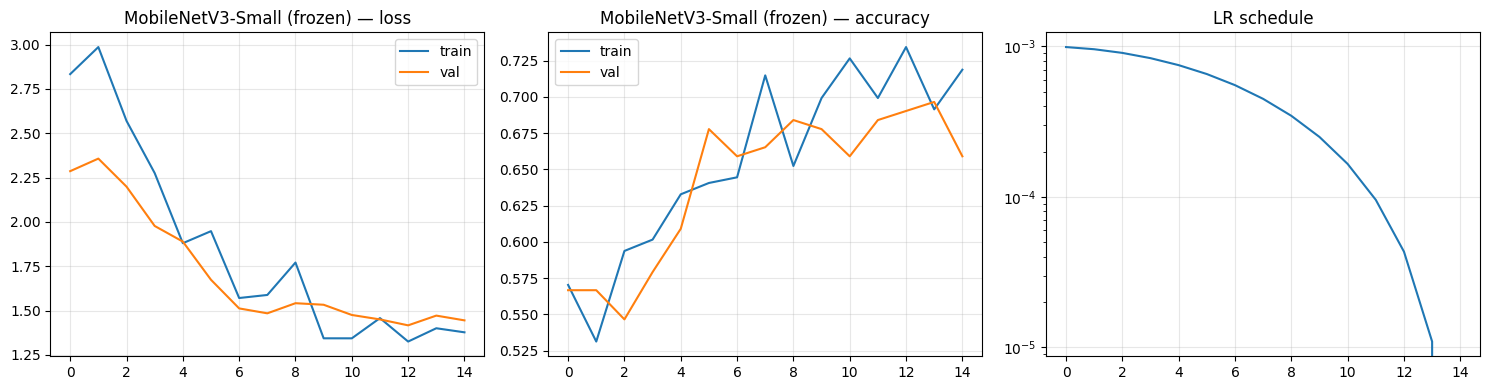

Trainable: 2,050  /  Total: 1,519,906  (0.13%)
[MobileNetV3-Small]  val_acc=0.6903


In [20]:
# Freeze everything, then unfreeze just the classifier
for p in mob.parameters():
    p.requires_grad = False
mob.get_classifier().requires_grad_(True)   # timm always has .get_classifier()

count_params(mob)
mob = mob.to(device)

opt_mob   = optim.AdamW(filter(lambda p: p.requires_grad, mob.parameters()),
                        lr=1e-3, weight_decay=1e-4)
sched_mob = torch.optim.lr_scheduler.CosineAnnealingLR(opt_mob, T_max=EPOCHS)

hist_mob = fit(mob, trainloader, valloader, opt_mob, crit,
               epochs=EPOCHS, scheduler=sched_mob, device=device,
               checkpoint='ckpt_mobilenet.pt', patience=EPOCHS)
plot_history(hist_mob, 'MobileNetV3-Small (frozen)')
register('MobileNetV3-Small', mob, hist_mob, 'ckpt_mobilenet.pt',
         note='timm, frozen backbone')

### Comparison: ResNet-18 vs MobileNetV3 for edge deployment

In [21]:
def measure_inference(model, n_runs=100, img_size=(1, 3, 224, 224)):
    """Measure average inference time (ms) and throughput (imgs/s)."""
    model.eval()
    x = torch.randn(img_size, device=device)
    # Warm-up
    with torch.no_grad():
        for _ in range(10):
            model(x)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.monotonic()
    with torch.no_grad():
        for _ in range(n_runs):
            model(x)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = (time.monotonic() - t0) / n_runs
    return elapsed * 1000  # ms

rn18_for_bench = torchvision.models.resnet18(weights='IMAGENET1K_V1').to(device)
mob_for_bench  = timm.create_model('mobilenetv3_small_100', pretrained=False).to(device)

bench_data = [
    ('ResNet-18',          rn18_for_bench,
     sum(p.numel() for p in rn18_for_bench.parameters())),
    ('MobileNetV3-Small',  mob_for_bench,
     sum(p.numel() for p in mob_for_bench.parameters())),
]
print(f'{"Model":25s} {"Params":>12s} {"Inference (ms)":>16s}')
print('-' * 56)
for name, m, params in bench_data:
    ms = measure_inference(m)
    print(f'{name:25s} {params:>12,} {ms:>14.2f}ms')

Model                           Params   Inference (ms)
--------------------------------------------------------
ResNet-18                   11,689,512          13.75ms
MobileNetV3-Small            2,542,856           6.72ms


# 9. `timm` — EfficientNet-B0

EfficientNet scales width, depth, and resolution together with a compound coefficient. B0 is the smallest variant (~5.3M params) but often outperforms ResNet-18 on the same task.

**Key `timm` convenience:** `timm.create_model(..., num_classes=N)` also sets the correct image size expectations via `model.default_cfg`. You can retrieve them:

In [22]:
eff = timm.create_model('efficientnet_b0', pretrained=True, num_classes=N_CLASSES)

cfg = eff.default_cfg
print(f'Input size  : {cfg["input_size"]}')
print(f'Interpolation: {cfg["interpolation"]}')
print(f'Mean / Std  : {cfg["mean"]} / {cfg["std"]}')
print()
count_params(eff)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Input size  : (3, 224, 224)
Interpolation: bicubic
Mean / Std  : (0.485, 0.456, 0.406) / (0.229, 0.224, 0.225)

Trainable: 4,010,110  /  Total: 4,010,110  (100.00%)


C:\Users\Ronkin\anaconda3\envs\ts\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ronkin\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


(4010110, 4010110)

Trainable: 2,562  /  Total: 4,010,110  (0.06%)
Ep 01/15 | 16.0s | lr 9.9e-04 | train 2.775/0.539 | val 2.566/0.584 ★
Ep 02/15 | 9.0s | lr 9.6e-04 | train 2.182/0.539 | val 2.090/0.615 ★
Ep 03/15 | 15.4s | lr 9.0e-04 | train 2.011/0.578 | val 1.866/0.626 ★
Ep 04/15 | 11.4s | lr 8.3e-04 | train 1.790/0.582 | val 1.763/0.689 ★
Ep 05/15 | 9.1s | lr 7.5e-04 | train 1.809/0.641 | val 1.752/0.689 ★
Ep 06/15 | 18.1s | lr 6.5e-04 | train 1.566/0.656 | val 1.651/0.697 ★
Ep 08/15 | 12.7s | lr 4.5e-04 | train 1.329/0.680 | val 1.578/0.726 ★
Ep 10/15 | 8.8s | lr 2.5e-04 | train 1.180/0.711 | val 1.578/0.720 ★
Ep 11/15 | 9.1s | lr 1.7e-04 | train 1.627/0.676 | val 1.476/0.745 ★
Ep 14/15 | 11.6s | lr 1.1e-05 | train 1.229/0.715 | val 1.458/0.697 ★
Ep 15/15 | 14.7s | lr 0.0e+00 | train 1.099/0.750 | val 1.482/0.708


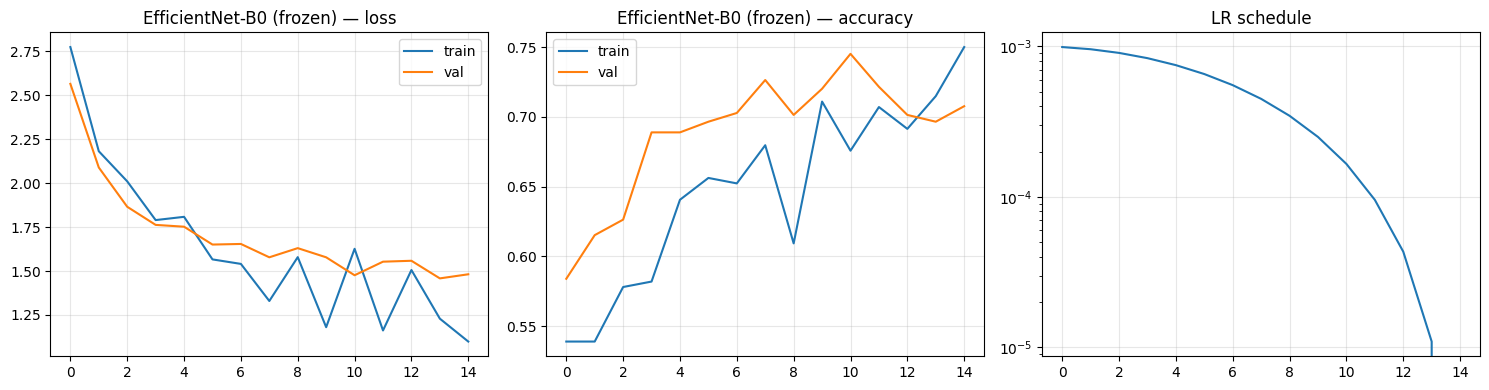

Trainable: 2,562  /  Total: 4,010,110  (0.06%)
[EfficientNet-B0]  val_acc=0.6965


In [23]:
# Freeze backbone, train head
for p in eff.parameters():
    p.requires_grad = False
eff.get_classifier().requires_grad_(True)
eff = eff.to(device)

count_params(eff)

opt_eff   = optim.AdamW(filter(lambda p: p.requires_grad, eff.parameters()),
                        lr=1e-3, weight_decay=1e-4)
sched_eff = torch.optim.lr_scheduler.CosineAnnealingLR(opt_eff, T_max=EPOCHS)

hist_eff = fit(eff, trainloader, valloader, opt_eff, crit,
               epochs=EPOCHS, scheduler=sched_eff, device=device,
               checkpoint='ckpt_efficientnet.pt', patience=EPOCHS)
plot_history(hist_eff, 'EfficientNet-B0 (frozen)')
register('EfficientNet-B0', eff, hist_eff, 'ckpt_efficientnet.pt',
         note='timm, frozen backbone')

# 10. Vision Transformer (ViT) — transfer learning

ViT divides the image into 16×16 patches and processes them as a sequence with a Transformer encoder. The classification token `[CLS]` accumulates global information and feeds the final head.

**Transfer learning differences from CNNs:**
* The `[CLS]` token head is accessed via `model.head` in `timm`.
* ViT is typically **more data-hungry** than CNNs — the frozen-backbone strategy is even more important here.
* The recommended LLRD decay for ViT is `0.65–0.75` (stronger than for CNNs).

```
Image → split into 14×14 = 196 patches (16×16 px each)
      → embed patches → prepend [CLS] token
      → 12 Transformer blocks
      → [CLS] output → head → N classes
```

In [24]:
# ViT-Tiny: lightest ViT variant in timm, still ImageNet pretrained
vit = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=N_CLASSES)

print('ViT children:')
for n, _ in vit.named_children():
    print(f'  {n}')
print()
print('Head:', vit.get_classifier())
count_params(vit)

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

ViT children:
  patch_embed
  pos_drop
  patch_drop
  norm_pre
  blocks
  norm
  fc_norm
  head_drop
  head

Head: Linear(in_features=192, out_features=2, bias=True)
Trainable: 5,524,802  /  Total: 5,524,802  (100.00%)


C:\Users\Ronkin\anaconda3\envs\ts\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ronkin\.cache\huggingface\hub\models--timm--vit_tiny_patch16_224.augreg_in21k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


(5524802, 5524802)

Trainable: 386  /  Total: 5,524,802  (0.01%)
Ep 01/15 | 14.5s | lr 9.9e-04 | train 0.638/0.648 | val 0.443/0.812 ★
Ep 02/15 | 7.9s | lr 9.6e-04 | train 0.319/0.863 | val 0.315/0.872 ★
Ep 03/15 | 11.5s | lr 9.0e-04 | train 0.269/0.883 | val 0.289/0.878 ★
Ep 04/15 | 12.9s | lr 8.3e-04 | train 0.317/0.840 | val 0.281/0.897 ★
Ep 05/15 | 7.9s | lr 7.5e-04 | train 0.302/0.836 | val 0.269/0.920 ★
Ep 06/15 | 13.4s | lr 6.5e-04 | train 0.241/0.906 | val 0.258/0.939 ★
Ep 07/15 | 10.8s | lr 5.5e-04 | train 0.217/0.922 | val 0.256/0.939 ★
Ep 08/15 | 7.8s | lr 4.5e-04 | train 0.217/0.918 | val 0.250/0.926 ★
Ep 10/15 | 9.1s | lr 2.5e-04 | train 0.236/0.887 | val 0.249/0.939 ★
Ep 15/15 | 14.6s | lr 0.0e+00 | train 0.239/0.906 | val 0.251/0.939


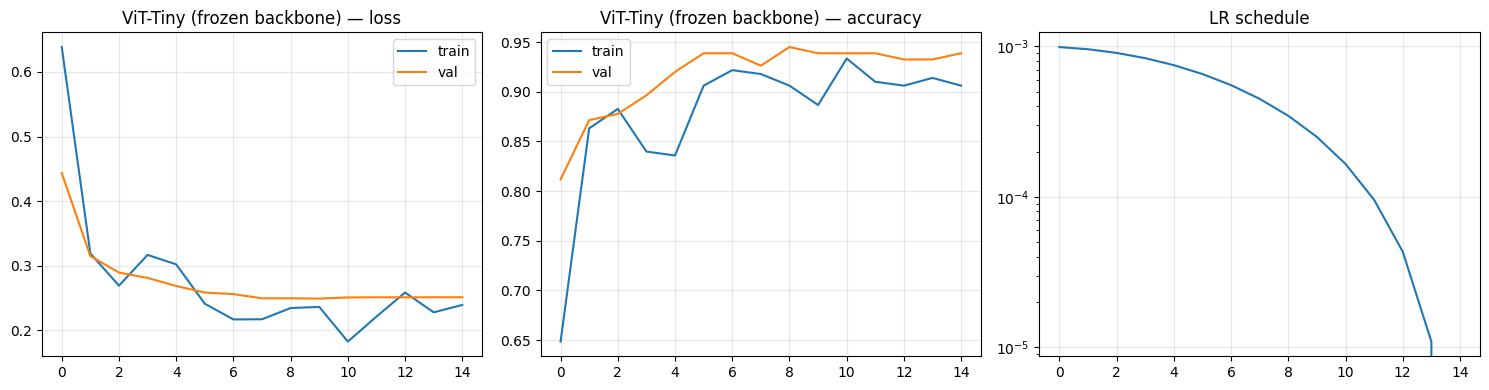

Trainable: 386  /  Total: 5,524,802  (0.01%)
[ViT-Tiny]  val_acc=0.9389


In [25]:
# Freeze everything, train only the head
for p in vit.parameters():
    p.requires_grad = False
vit.get_classifier().requires_grad_(True)
vit = vit.to(device)

count_params(vit)

opt_vit   = optim.AdamW(filter(lambda p: p.requires_grad, vit.parameters()),
                        lr=1e-3, weight_decay=1e-4)
sched_vit = torch.optim.lr_scheduler.CosineAnnealingLR(opt_vit, T_max=EPOCHS)

hist_vit = fit(vit, trainloader, valloader, opt_vit, crit,
               epochs=EPOCHS, scheduler=sched_vit, device=device,
               checkpoint='ckpt_vit.pt', patience=EPOCHS)
plot_history(hist_vit, 'ViT-Tiny (frozen backbone)')
register('ViT-Tiny', vit, hist_vit, 'ckpt_vit.pt',
         note='timm, frozen backbone')

### ViT attention visualisation

ViT attention maps show *which patches* the model attends to for its classification decision — it is the CNN-free equivalent of Grad-CAM and requires no hooks.

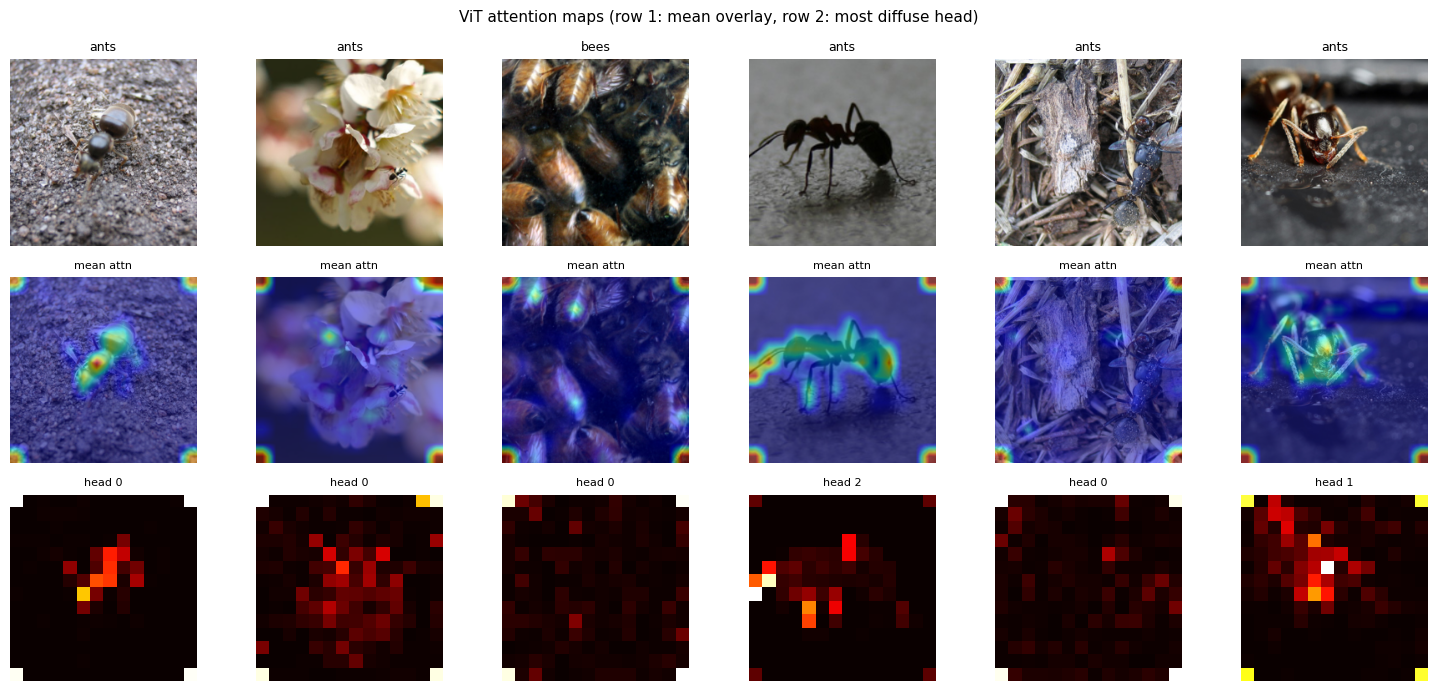

In [26]:
@torch.no_grad()
def get_attention_map(model, image_tensor, layer_idx=-1):
    """
    Extract the [CLS]-token attention weights from one Transformer block.
    Returns: attention (n_heads, H_patches, W_patches).
    """
    model.eval()
    x = image_tensor.unsqueeze(0).to(device)

    # Forward through patch embedding + cls token
    B = x.shape[0]
    x_tok = model.patch_embed(x)
    cls = model.cls_token.expand(B, -1, -1)
    x_tok = torch.cat([cls, x_tok], dim=1)
    x_tok = x_tok + model.pos_embed

    # Run through blocks up to layer_idx
    n_blocks = len(model.blocks)
    target   = n_blocks + layer_idx if layer_idx < 0 else layer_idx
    for i, blk in enumerate(model.blocks):
        if i < target:
            x_tok = blk(x_tok)
        else:
            # Extract raw attention from the last block
            norm_x   = blk.norm1(x_tok)
            B2, N, C = norm_x.shape
            qkv = blk.attn.qkv(norm_x).reshape(B2, N, 3,
                  blk.attn.num_heads, C // blk.attn.num_heads).permute(2, 0, 3, 1, 4)
            q, k, _ = qkv.unbind(0)
            attn = (q @ k.transpose(-2, -1)) * blk.attn.scale
            attn = attn.softmax(dim=-1)       # (B, heads, N, N)
            # CLS attends to all patch tokens
            cls_attn = attn[0, :, 0, 1:]      # (heads, n_patches)
            n_patches = int(cls_attn.shape[-1] ** 0.5)
            return cls_attn.reshape(-1, n_patches, n_patches).cpu()


def show_vit_attention(model, dataset, n=6):
    import matplotlib.cm as mpl_cm
    fig, axs = plt.subplots(3, n, figsize=(n * 2.5, 7))
    indices  = random.sample(range(len(dataset)), n)
    heads_shown = min(vit.blocks[-1].attn.num_heads, 3)

    for col, idx in enumerate(indices):
        img, label = dataset[idx]
        att = get_attention_map(model, img)       # (n_heads, H, W)
        img_show = denorm(img).permute(1, 2, 0).numpy()

        # Row 0: original
        axs[0, col].imshow(img_show)
        axs[0, col].set_title(CLASS_NAMES[label], fontsize=9)
        axs[0, col].axis('off')

        # Row 1: mean attention across heads
        mean_att = att.mean(0).numpy()
        mean_att = (mean_att - mean_att.min()) / (mean_att.max() - mean_att.min() + 1e-8)
        from torchvision.transforms.functional import resize
        att_up = F.interpolate(torch.tensor(mean_att).unsqueeze(0).unsqueeze(0).float(),
                               size=(224, 224), mode='bilinear', align_corners=False
                               ).squeeze().numpy()
        overlay = 0.5 * img_show + 0.5 * mpl_cm.jet(att_up)[:, :, :3]
        axs[1, col].imshow(np.clip(overlay, 0, 1))
        axs[1, col].set_title('mean attn', fontsize=8)
        axs[1, col].axis('off')

        # Row 2: head with highest entropy (most diffuse)
        h_idx = int(att.var(dim=(1, 2)).argmax())
        h_att = att[h_idx].numpy()
        h_att = (h_att - h_att.min()) / (h_att.max() - h_att.min() + 1e-8)
        axs[2, col].imshow(h_att, cmap='hot')
        axs[2, col].set_title(f'head {h_idx}', fontsize=8)
        axs[2, col].axis('off')

    plt.suptitle('ViT attention maps (row 1: mean overlay, row 2: most diffuse head)',
                 fontsize=11)
    plt.tight_layout(); plt.show()


show_vit_attention(vit, valset, n=6)

# 11. Custom heads in `timm` — deep-dive

`timm` makes it easy to attach any custom head. Three patterns:

### Pattern A — `reset_classifier` (simplest)

```python
model.reset_classifier(num_classes=N, global_pool='avg')
```

### Pattern B — replace `model.head` with your own module

```python
model.head = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.num_features, 256),
    nn.GELU(),
    nn.Linear(256, N),
)
```

### Pattern C — `forward_features` + external head

```python
feats = model.forward_features(x)      # (B, C, H, W) or (B, N, C) for ViT
# do your own aggregation
```

In [27]:
class MultiScaleHead(nn.Module):
    """
    Attach to any timm CNN backbone.
    Aggregates features at two scales (from the last two stages),
    concatenates, then classifies.

    Illustrates that you don't have to use only the final feature map.
    """
    def __init__(self, backbone_name='mobilenetv3_small_100', n_classes=2):
        super().__init__()
        # Create backbone that exposes intermediate features
        self.backbone = timm.create_model(
            backbone_name, pretrained=True,
            features_only=True,          # returns list of feature maps
            out_indices=(3, 4),          # stages 3 and 4
        )
        for p in self.backbone.parameters():
            p.requires_grad = False

        feat_info   = self.backbone.feature_info.channels()  # [C_stage3, C_stage4]
        c3, c4      = feat_info[-2], feat_info[-1]

        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.head   = nn.Sequential(
            nn.Linear(c3 + c4, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )
        self.head.apply(init_weights)

    def forward(self, x):
        f3, f4   = self.backbone(x)                     # two feature maps
        v3       = self.gap(f3).flatten(1)              # (B, C3)
        v4       = self.gap(f4).flatten(1)              # (B, C4)
        combined = torch.cat([v3, v4], dim=1)           # (B, C3+C4)
        return self.head(combined)


ms_model = MultiScaleHead('mobilenetv3_small_100', N_CLASSES).to(device)
count_params(ms_model)
summary(ms_model, (1, 3, 224, 224), device=device.type)

Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Trainable: 160,514  /  Total: 1,087,522  (14.76%)


Layer (type:depth-idx)                             Output Shape              Param #
MultiScaleHead                                     [1, 2]                    --
├─MobileNetV3Features: 1-1                         [1, 48, 14, 14]           --
│    └─Conv2d: 2-1                                 [1, 16, 112, 112]         (432)
│    └─BatchNorm2d: 2-2                            [1, 16, 112, 112]         (32)
│    └─Hardswish: 2-3                              [1, 16, 112, 112]         --
│    └─Sequential: 2-4                             --                        --
│    │    └─Sequential: 3-1                        [1, 16, 56, 56]           (744)
│    │    └─Sequential: 3-2                        [1, 24, 28, 28]           (9,280)
│    │    └─Sequential: 3-3                        [1, 40, 14, 14]           (128,264)
│    │    └─Sequential: 3-4                        [1, 48, 14, 14]           (51,768)
│    │    └─Sequential: 3-5                        [1, 96, 7, 7]             (680,040)
│ 

Ep 01/15 | 7.7s | lr 9.9e-04 | train 0.585/0.734 | val 0.264/0.873 ★
Ep 05/15 | 14.0s | lr 7.5e-04 | train 0.201/0.898 | val 0.384/0.842
Ep 10/15 | 9.4s | lr 2.5e-04 | train 0.211/0.926 | val 0.333/0.865
Ep 15/15 | 6.8s | lr 0.0e+00 | train 0.194/0.914 | val 0.305/0.878


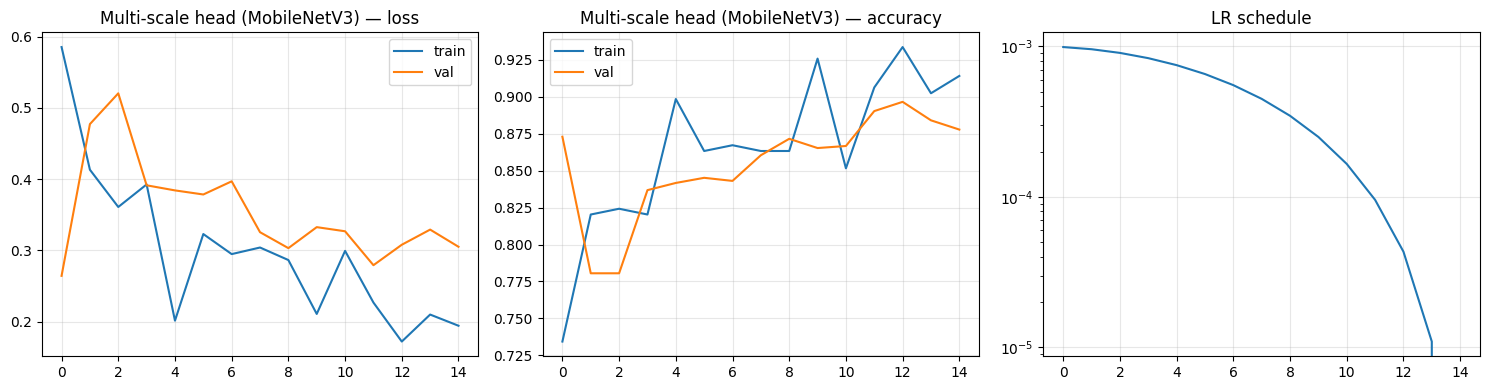

Trainable: 160,514  /  Total: 1,087,522  (14.76%)
[Multi-scale head]  val_acc=0.8729


In [28]:
opt_ms   = optim.AdamW(filter(lambda p: p.requires_grad, ms_model.parameters()),
                       lr=1e-3, weight_decay=1e-4)
sched_ms = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ms, T_max=EPOCHS)

hist_ms = fit(ms_model, trainloader, valloader, opt_ms, crit,
              epochs=EPOCHS, scheduler=sched_ms, device=device,
              checkpoint='ckpt_multiscale.pt', patience=EPOCHS)
plot_history(hist_ms, 'Multi-scale head (MobileNetV3)')
register('Multi-scale head', ms_model, hist_ms, 'ckpt_multiscale.pt',
         note='features_only, 2 stages')

# 12. Feature extraction & embedding visualisation

A pretrained backbone is a powerful **feature extractor** even without any fine-tuning. We can project the 512-dim ResNet-18 features down to 2D with t-SNE and see if the classes are already separable.

**This answers the key question:** *how good are the features before we even train the head?*

In [29]:
@torch.no_grad()
def extract_features(backbone, loader, device):
    """
    Run all images through the backbone (no head) and return
    (features: np.ndarray [N, D], labels: np.ndarray [N]).
    """
    backbone.eval()
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        # timm: forward_features returns spatial map; avgpool it
        f = backbone.forward_features(x)
        if f.dim() == 4:                         # CNN: (B, C, H, W)
            f = f.mean(dim=(2, 3))               # → (B, C)
        elif f.dim() == 3:                       # ViT: (B, N, C)
            f = f[:, 0]                          # [CLS] token
        feats.append(f.cpu().numpy())
        labels.append(y.numpy())
    return np.vstack(feats), np.concatenate(labels)


# Use the frozen ResNet-18 backbone
rn18_extractor = timm.create_model('resnet18', pretrained=True, num_classes=0).to(device)
for p in rn18_extractor.parameters():
    p.requires_grad = False

feats_train, labels_train = extract_features(rn18_extractor, trainloader, device)
feats_val,   labels_val   = extract_features(rn18_extractor, valloader,   device)

print(f'Feature shape: {feats_train.shape}')  # (N, 512)

Feature shape: (244, 512)


In [30]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

all_feats  = np.vstack([feats_train, feats_val])
all_labels = np.concatenate([labels_train, labels_val])
split_flag = np.array(['train'] * len(feats_train) + ['val'] * len(feats_val))

# Pre-reduce with PCA to 50 dims before t-SNE (speeds it up)
pca     = PCA(n_components=50, random_state=SEED)
reduced = pca.fit_transform(all_feats)
print(f'PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}')

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
emb  = tsne.fit_transform(reduced)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
colors   = ['#e41a1c', '#377eb8']

# Left: coloured by class
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = all_labels == cls_idx
    axs[0].scatter(emb[mask, 0], emb[mask, 1], c=colors[cls_idx],
                   label=cls_name, alpha=0.7, s=20)
axs[0].set_title('ResNet-18 features — by class')
axs[0].legend(); axs[0].axis('off')

# Right: coloured by split
for split, color, marker in [('train', '#4dac26', 'o'), ('val', '#d01c8b', '^')]:
    mask = split_flag == split
    axs[1].scatter(emb[mask, 0], emb[mask, 1], c=color,
                   label=split, alpha=0.7, s=20, marker=marker)
axs[1].set_title('ResNet-18 features — by split')
axs[1].legend(); axs[1].axis('off')

plt.suptitle('t-SNE of ResNet-18 features (before any fine-tuning)', fontsize=12)
plt.tight_layout(); plt.show()

PCA variance explained: 74.7%


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

**What to look for:**
* **Well-separated clusters by class** → the pretrained features are already discriminative. A simple linear head will work well.
* **Mixed clusters** → the task is far from ImageNet; you need to fine-tune more layers.
* **Train/val overlap** → no distribution shift; the split is representative.

# 13. Comparison of all strategies

In [ ]:
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
vals  = [float(r['final_val_acc']) for r in results]
names = [r['model'] for r in results]
bars  = ax.bar(names, vals, color=plt.cm.viridis(np.linspace(0.2, 0.85, len(names))))
ax.set_ylabel('Val accuracy')
ax.set_title('Final val accuracy — all transfer learning strategies')
ax.set_ylim(min(vals) - 0.05, 1.02)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=20, ha='right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## Transfer learning decision guide

```
Is there a pretrained model available for your modality?
  └─ NO  → Train from scratch (need large dataset)
  └─ YES ↓
       Is the target domain similar to pre-training domain?
         └─ VERY SIMILAR (natural photos → ImageNet) ─────────────────────────┐
         └─ SOMEWHAT SIMILAR (medical, satellite, documents) ──────────────┐  │
         └─ VERY DIFFERENT (spectrograms, thermal, synthetic) ──────────┐  │  │
                                                                        │  │  │
       How large is the target dataset?                                  │  │  │
         └─ SMALL  (< 1k)  ───────────────────────────────────────────> FROZEN BACKBONE
         └─ MEDIUM (1k–50k) ──────────────────────────────────────────> PARTIAL FINE-TUNE (last 1-2 blocks)
         └─ LARGE  (> 50k)  ──────────────────────────────────────────> FULL FINE-TUNE with LLRD
```

| Strategy | #Trainable | Dataset size | Domain similarity |
|---|---|---|---|
| Frozen backbone | ~1k | Any | High |
| Partial fine-tune | ~1M | Medium | Medium–High |
| Full fine-tune + LLRD | All | Large | Any |
| Custom head | ~100k | Small | High |

# 14. Exercises

### __1.__ Train on CIFAR-10 with ResNet-18 weights

ResNet-18 expects 224×224 inputs; CIFAR-10 images are 32×32. You have two options:
* **Upsample** CIFAR images to 224 with `transforms.Resize(224)`.
* **Replace the stem** (first conv + maxpool) with a conv that works at 32×32.

Implement both, compare accuracy, and explain the trade-offs.

**Hints:**
* For the stem replacement: swap `model.conv1` with `nn.Conv2d(3, 64, 3, padding=1, bias=False)` and remove `model.maxpool` by replacing it with `nn.Identity()`.
* CIFAR-10 has 10 classes — don't forget to update `num_classes`.

In [ ]:
# Your code here

### __2.__ One-Cycle LR schedule

Replace the cosine scheduler with `OneCycleLR`, which ramps the LR up then down in a single cycle and is known for faster convergence:

```python
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-2,
    steps_per_epoch=len(trainloader), epochs=EPOCHS,
)
# Note: OneCycleLR steps per BATCH, not per epoch
```

Apply it to Strategy 2 (partial fine-tune) and compare convergence speed.

**Hints:**
* You need to call `scheduler.step()` inside `train_epoch`, not in `fit` — modify `fit` to accept a `per_batch_scheduler` argument.

In [ ]:
# Your code here

### __3.__ EfficientNet vs MobileNetV3 — accuracy/speed Pareto frontier

For a **mobile deployment** scenario, we care about both accuracy and inference latency.

1. Take EfficientNet-B0 and MobileNetV3-Small from earlier experiments.
2. Measure their inference time on a single image (use `measure_inference`).
3. Fine-tune both with partial fine-tuning (last 2 blocks + head).
4. Plot accuracy vs latency (scatter plot). Which is on the Pareto frontier?

In [ ]:
# Your code here

### <code style="color:red">__4.*__</code> LLRD for ViT

Apply layer-wise LR decay to `vit_tiny_patch16_224`. ViT has 12 transformer blocks — the recommended decay is `0.65`.

```
head:      lr = base_lr
block[11]: lr = base_lr × 0.65¹
block[10]: lr = base_lr × 0.65²
...
block[0]:  lr = base_lr × 0.65^12
patch_embed: lr = base_lr × 0.65^13
```

Compare convergence vs. frozen-backbone ViT from Section 10.

**Hints:**
* `model.blocks` is a `nn.Sequential` of Transformer blocks.
* `model.patch_embed` is the patch embedding.
* Build one parameter group per block with its own `lr`.

In [ ]:
# Your code here

### <code style="color:red">__5.*__</code> Your own dataset

Use `torchvision.datasets.ImageFolder` to load **your own** 2–5 class image dataset (you can use Google Images or any other source — even 50 images per class is enough).

Apply the **best strategy** from this workshop and report:
* Accuracy before fine-tuning (zero-shot quality of ImageNet features).
* Accuracy after fine-tuning.
* t-SNE of features before and after.
* 3 Grad-CAM examples (from WS2) on your data.

In [ ]:
# Your code here

### <code style="color:red">__6.*__</code> Cross-architecture feature similarity

Do ResNet and ViT learn the same representations?

1. Extract features from both backbones on the validation set.
2. For each image, find its 5 nearest neighbours in each feature space.
3. Are the neighbours the same across architectures?
4. Use CKA (Centred Kernel Alignment) or just cosine similarity to measure feature-space overlap.

**Bonus:** plot the t-SNE of both feature spaces side-by-side and qualitatively compare the cluster structure.

In [ ]:
# Your code here